In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo
import pickle
from constants import FEATURES


# use tex
plt.rcParams["text.usetex"] = True
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd
from signal_region import get_SR_CR_cut, compute_sr_stats
from correct_systematic_error import get_histograms, get_quantiles_with_weights

metadata = TrainingInfo.load_metadata()

In [7]:
import tqdm
from ks_test import max_cdf_diff, p_value_ks, tilt_correction_iterative

SR_size = 0.2
experiment_name = "CR_fvt_training_ensemble_max"

hashes = TrainingInfo.find(
    {
        "experiment_name": experiment_name,
        "signal_region": lambda x: x["4b_in_SR"] == SR_size,
        "dataset": lambda x: (x["signal_ratio"] == 0.0 and x["seed"] == 0),
    }
)

for hash_ in tqdm.tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    signal_filename = CR_fvt_tinfo.hparams["dataset"]["signal_filename"]

    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )

    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )

    for SB_size in [0.05, 0.1, 0.15]:
        SR_cut, SB_cut = get_SR_CR_cut(
            SR_stats_train,
            events_train,
            {"4b_in_SR": SR_size - SB_size, "4b_in_CR": SB_size},
        )
        SR_SB_idx = SR_stats_tst >= SB_cut
        SR_stats_tst_SR_SB = SR_stats_tst[SR_SB_idx]
        events_tst_SR_SB = events_tst[SR_SB_idx]
        fvt_scores_tst_SR_SB = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
        reweights_tst_SR_SB = fvt_scores_tst_SR_SB / (1 - fvt_scores_tst_SR_SB)
        rw_tst_SR_SB = np.where(
            events_tst_SR_SB.is_4b,
            events_tst_SR_SB.weights,
            reweights_tst_SR_SB * events_tst_SR_SB.weights,
        )

        SB_idx_int = np.where((SR_stats_tst >= SB_cut) & (SR_stats_tst < SR_cut))[0]
        SR_idx_int = np.where(SR_stats_tst >= SR_cut)[0]
        SR_SB_idx_int = np.where(SR_SB_idx)[0]

        SR_idx = np.isin(SR_SB_idx_int, SR_idx_int)
        SB_idx = np.isin(SR_SB_idx_int, SB_idx_int)

        SR_stats_SB = SR_stats_tst_SR_SB[SB_idx]
        SR_stats_SR = SR_stats_tst_SR_SB[SR_idx]

        is_4b_tst_SB = events_tst_SR_SB.is_4b[SB_idx]
        is_4b_tst_SR = events_tst_SR_SB.is_4b[SR_idx]

        rw_tst_SR = rw_tst_SR_SB[SR_idx]
        rw_tst_SB = rw_tst_SR_SB[SB_idx]
        
        # randomly sample half of is_4b_tst_SB and ~is_4b_tst_SB
        
        is_4b_tst_SB_int = np.where(is_4b_tst_SB)[0]
        isnt_4b_tst_SB_int = np.where(~is_4b_tst_SB)[0]
        
        theta_SB_list = []
        
        for rnd in tqdm.tqdm(range(200)):
            np.random.seed(rnd)
            is_4b_tst_SB_rnd = np.random.choice(is_4b_tst_SB_int, size=len(is_4b_tst_SB_int)//2, replace=False)
            isnt_4b_tst_SB_rnd = np.random.choice(isnt_4b_tst_SB_int, size=len(isnt_4b_tst_SB_int)//2, replace=False)
            
            theta_SB = tilt_correction_iterative(
                SR_stats_SB[is_4b_tst_SB_rnd],
                SR_stats_SB[isnt_4b_tst_SB_rnd],
                rw_tst_SB[is_4b_tst_SB_rnd],
                rw_tst_SB[isnt_4b_tst_SB_rnd],
            )
            theta_SB_list.append(theta_SB)
            
        theta_SB_mean = np.mean(theta_SB_list)
        theta_SB_std = np.std(theta_SB_list)
        
        max_diff_SR = max_cdf_diff(
            SR_stats_SR[is_4b_tst_SR],
            SR_stats_SR[~is_4b_tst_SR],
            rw_tst_SR[is_4b_tst_SR],
            rw_tst_SR[~is_4b_tst_SR],
        )
        theta_SR = tilt_correction_iterative(
            SR_stats_SR[is_4b_tst_SR],
            SR_stats_SR[~is_4b_tst_SR],
            rw_tst_SR[is_4b_tst_SR],
            rw_tst_SR[~is_4b_tst_SR],
        )

        theta_SR_clipped = np.clip(theta_SR, 
                                   theta_SB_mean - 1.96 * theta_SB_std, 
                                   theta_SB_mean + 1.96 * theta_SB_std)
        

        # rw_tst_SB_corrected = np.copy(rw_tst_SB)
        # rw_tst_SB_corrected[~is_4b_tst_SB] = rw_tst_SB[~is_4b_tst_SB] * np.exp(
        #     theta_SB * SR_stats_SB[~is_4b_tst_SB]
        # )
        rw_tst_SR_corrected = np.copy(rw_tst_SR)
        rw_tst_SR_corrected[~is_4b_tst_SR] = rw_tst_SR[~is_4b_tst_SR] * np.exp(
            theta_SR_clipped * SR_stats_SR[~is_4b_tst_SR]
        )

        # max_diff_SB_corrected = max_cdf_diff(
        #     SR_stats_SB[is_4b_tst_SB],
        #     SR_stats_SB[~is_4b_tst_SB],
        #     rw_tst_SB_corrected[is_4b_tst_SB],
        #     rw_tst_SB_corrected[~is_4b_tst_SB],
        # )
        max_diff_SR_corrected = max_cdf_diff(
            SR_stats_SR[is_4b_tst_SR],
            SR_stats_SR[~is_4b_tst_SR],
            rw_tst_SR_corrected[is_4b_tst_SR],
            rw_tst_SR_corrected[~is_4b_tst_SR],
        )

        SB_correction_results = {
            "theta_SB": theta_SB,
            "theta_SR": theta_SR,
            "theta_SR_clipped": theta_SR_clipped,
        }
        
        print("SB_size: ", SB_size)
        print("theta_SB_mean: ", theta_SB_mean)
        print("theta_SB_std: ", theta_SB_std)
        print("theta_SR: ", theta_SR)
        print("theta_SR_clipped: ", theta_SR_clipped)
        print("max_diff_SR: ", max_diff_SR)
        print("max_diff_SR_corrected: ", max_diff_SR_corrected)

        SB_correction_results["original"] = {
            "max_diff_SB": max_diff_SB,
            "max_diff_SR": max_diff_SR,
            "W_4b_SB": np.sum(rw_tst_SB[is_4b_tst_SB]),
            "W2_4b_SB": np.sum(rw_tst_SB[is_4b_tst_SB] ** 2),
            "W_3b_SB": np.sum(rw_tst_SB[~is_4b_tst_SB]),
            "W2_3b_SB": np.sum(rw_tst_SB[~is_4b_tst_SB] ** 2),
            "W_4b_SR": np.sum(rw_tst_SR[is_4b_tst_SR]),
            "W2_4b_SR": np.sum(rw_tst_SR[is_4b_tst_SR] ** 2),
            "W_3b_SR": np.sum(rw_tst_SR[~is_4b_tst_SR]),
            "W2_3b_SR": np.sum(rw_tst_SR[~is_4b_tst_SR] ** 2),
        }

        SB_correction_results["corrected"] = {
            # "max_diff_SB": max_diff_SB_corrected,
            "max_diff_SR": max_diff_SR_corrected,
            # "W_4b_SB": np.sum(rw_tst_SB_corrected[is_4b_tst_SB]),
            # "W2_4b_SB": np.sum(rw_tst_SB_corrected[is_4b_tst_SB] ** 2),
            # "W_3b_SB": np.sum(rw_tst_SB_corrected[~is_4b_tst_SB]),
            # "W2_3b_SB": np.sum(rw_tst_SB_corrected[~is_4b_tst_SB] ** 2),
            "W_4b_SR": np.sum(rw_tst_SR_corrected[is_4b_tst_SR]),
            "W2_4b_SR": np.sum(rw_tst_SR_corrected[is_4b_tst_SR] ** 2),
            "W_3b_SR": np.sum(rw_tst_SR_corrected[~is_4b_tst_SR]),
            "W2_3b_SR": np.sum(rw_tst_SR_corrected[~is_4b_tst_SR] ** 2),
        }



100%|██████████| 200/200 [00:08<00:00, 22.80it/s]


SB_size:  0.05
theta_SB_mean:  -0.8183045376133344
theta_SB_std:  1.7157722609294555
theta_SR:  -0.38053213572129607
theta_SR_clipped:  -0.38053213572129607
max_diff_SR:  0.0077664843
max_diff_SR_corrected:  0.0035114957


100%|██████████| 200/200 [00:19<00:00, 10.30it/s]


SB_size:  0.1
theta_SB_mean:  0.17475586772615148
theta_SB_std:  0.6684523331142611
theta_SR:  -0.2852847490717636
theta_SR_clipped:  -0.2852847490717636
max_diff_SR:  0.007463941
max_diff_SR_corrected:  0.0046810186


 20%|██        | 1/5 [01:10<04:41, 70.41s/it]

...

SB_size:  0.05
theta_SB_mean:  -0.4716307566442539
theta_SB_std:  2.1574555648722287
theta_SR:  0.20068598419311456
theta_SR_clipped:  0.20068598419311456
max_diff_SR:  0.0069921575
max_diff_SR_corrected:  0.002865906


100%|██████████| 200/200 [00:26<00:00,  7.51it/s]


SB_size:  0.1
theta_SB_mean:  0.24777044138689383
theta_SB_std:  0.6755023272418631
theta_SR:  0.1638628162909299
theta_SR_clipped:  0.1638628162909299
max_diff_SR:  0.0064414977
max_diff_SR_corrected:  0.0030348753


100%|██████████| 5/5 [06:22<00:00, 76.51s/it]

SB_size:  0.15
theta_SB_mean:  0.41338382289538594
theta_SB_std:  0.27016107123574384
theta_SR:  0.1101831920677796
theta_SR_clipped:  0.1101831920677796
max_diff_SR:  0.005686642
max_diff_SR_corrected:  0.0033289166


In [31]:
from plots import plot_cdf
from ks_test import max_cdf_diff, p_value_ks, tilt_correction_iterative
from ancillary_features import get_m4j

def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

signal_ratio = 0.0
signal_filename = "HH4b_picoAOD.h5"
SR_size = 0.2
SB_size = 0.1

sig_level = 0.05
noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]

hashes = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                "dataset": lambda x: x["signal_ratio"] == signal_ratio, 
                                "signal_region": lambda x: x["4b_in_SR"] == SR_size})

hashes = sorted(hashes, key=lambda x: metadata[x]["dataset"]["seed"])

results_list = []

for hash_ in hashes:
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    ensemble_mode = CR_fvt_tinfo.hparams["signal_region"]["ensemble_mode"]
    stats_type = CR_fvt_tinfo.hparams["signal_region"]["stats_type"]
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    
    SR_stats_train, SR_stats_tst = compute_sr_stats(
        SR_stats_hashes,
        signal_filename,
        ensemble_mode,
        stats_type,
    )
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    if noise_scale not in [2.0, np.inf]:
        continue
        
    msamples = MotherSamples.load(smeared_tinfo.ms_hash)
    events_train = events_from_scdinfo(
        msamples.scdinfo[smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    events_tst = events_from_scdinfo(
        msamples.scdinfo[~smeared_tinfo.ms_idx], FEATURES, signal_filename
    )
    SR_cut, SB_cut = get_SR_CR_cut(
            SR_stats_train, events_train, {"4b_in_SR": SR_size - SB_size, 
                                           "4b_in_CR": SB_size}
        )
    SR_SB_idx = SR_stats_tst >= SB_cut
    SR_stats_tst_SR_SB = SR_stats_tst[SR_SB_idx]
    events_tst_SR_SB = events_tst[SR_SB_idx]
    fvt_scores_tst_SR_SB = CR_fvt_tinfo.aux_info["fvt_scores_tst_SR"]
    reweights_tst_SR_SB = fvt_scores_tst_SR_SB / (1 - fvt_scores_tst_SR_SB)
    rw_tst_SR_SB = np.where(events_tst_SR_SB.is_4b, events_tst_SR_SB.weights, 
                         reweights_tst_SR_SB * events_tst_SR_SB.weights)
    is_4b_tst_SR_SB = events_tst_SR_SB.is_4b
    x_stats_SR_SB = SR_stats_tst_SR_SB
    
    SB_idx_int = np.where((SR_stats_tst >= SB_cut) & (SR_stats_tst < SR_cut))[0]
    SR_idx_int = np.where(SR_stats_tst >= SR_cut)[0]
    SR_SB_idx_int = np.where(SR_SB_idx)[0]
    
    SR_idx = np.isin(SR_SB_idx_int, SR_idx_int)
    SB_idx = np.isin(SR_SB_idx_int, SB_idx_int)
    
    x_stats_SB = SR_stats_tst_SR_SB[SB_idx]
    x_stats_SR = SR_stats_tst_SR_SB[SR_idx]
    
    is_4b_tst_SB = events_tst_SR_SB.is_4b[SB_idx]
    is_4b_tst_SR = events_tst_SR_SB.is_4b[SR_idx]
    
    rw_tst_SR = rw_tst_SR_SB[SR_idx]
    rw_tst_SB = rw_tst_SR_SB[SB_idx]
    
    events_tst_SB = events_tst_SR_SB[SB_idx]
    events_tst_SR = events_tst_SR_SB[SR_idx]
    
    max_diff_SB = max_cdf_diff(x_stats_SB[is_4b_tst_SB], x_stats_SB[~is_4b_tst_SB], 
                            rw_tst_SB[is_4b_tst_SB], rw_tst_SB[~is_4b_tst_SB])
    p_value_SB = p_value_ks(x_stats_SB[is_4b_tst_SB], x_stats_SB[~is_4b_tst_SB], 
                            rw_tst_SB[is_4b_tst_SB], rw_tst_SB[~is_4b_tst_SB])
    max_diff_SR = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    p_value_SR = p_value_ks(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                            rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    theta_SB = tilt_correction_iterative(x_stats_SB[is_4b_tst_SB], x_stats_SB[~is_4b_tst_SB], 
                                         rw_tst_SB[is_4b_tst_SB], rw_tst_SB[~is_4b_tst_SB])
    print(f"SB correction: {theta_SB:.4f}")
    theta_SR = tilt_correction_iterative(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                                        rw_tst_SR[is_4b_tst_SR], rw_tst_SR[~is_4b_tst_SR])
    if np.abs(theta_SR) > np.abs(theta_SB):
        print(f"Clipping SR correction: {theta_SR:.4f} -> {np.clip(theta_SR, -np.abs(theta_SB), np.abs(theta_SB)):.4f}")
        theta_SR = np.clip(theta_SR, -np.abs(theta_SB), np.abs(theta_SB))
    else:
        print(f"No clipping needed for SR correction: {theta_SR:.4f}")
        
    rw_tst_SB_corr = np.copy(rw_tst_SB)
    rw_tst_SB_corr[~is_4b_tst_SB] = rw_tst_SB[~is_4b_tst_SB] * np.exp(
        theta_SB * x_stats_SB[~is_4b_tst_SB])
    rw_tst_SR_corr = np.copy(rw_tst_SR)
    rw_tst_SR_corr[~is_4b_tst_SR] = rw_tst_SR[~is_4b_tst_SR] * np.exp(
        theta_SR * x_stats_SR[~is_4b_tst_SR])
    
    max_diff_SB_corr = max_cdf_diff(x_stats_SB[is_4b_tst_SB], x_stats_SB[~is_4b_tst_SB], 
                                   rw_tst_SB_corr[is_4b_tst_SB], rw_tst_SB_corr[~is_4b_tst_SB])
    p_value_SB_corr = p_value_ks(x_stats_SB[is_4b_tst_SB], x_stats_SB[~is_4b_tst_SB], 
                                rw_tst_SB_corr[is_4b_tst_SB], rw_tst_SB_corr[~is_4b_tst_SB])
    max_diff_SR_corr = max_cdf_diff(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                                   rw_tst_SR_corr[is_4b_tst_SR], rw_tst_SR_corr[~is_4b_tst_SR])
    p_value_SR_corr = p_value_ks(x_stats_SR[is_4b_tst_SR], x_stats_SR[~is_4b_tst_SR], 
                                rw_tst_SR_corr[is_4b_tst_SR], rw_tst_SR_corr[~is_4b_tst_SR])
    
    results_list.append({
        "seed": seed,
        "signal_ratio": signal_ratio,
        "noise_scale": noise_scale,
        "theta_SB": theta_SB,
        "theta_SR": theta_SR,
        "max_diff_SB": max_diff_SB,
        "max_diff_SR": max_diff_SR,
        "p_value_SB": p_value_SB,
        "p_value_SR": p_value_SR,
        "max_diff_SB_corr": max_diff_SB_corr,
        "max_diff_SR_corr": max_diff_SR_corr,
        "p_value_SB_corr": p_value_SB_corr,
        "p_value_SR_corr": p_value_SR_corr,
    })
    
    print(f"Corrected p-value in SR: {p_value_SR_corr:.3e}")
    filtered = [v for v in results_list if v["noise_scale"] == noise_scale]
    print(f'Rejection rate of noise scale = {noise_scale}: {sum([v["p_value_SR_corr"] < sig_level for v in filtered])}/{len(filtered)}')

SB correction: 0.1028
Clipping SR correction: -0.2853 -> -0.1028
Corrected p-value in SR: 4.234e-01
Rejection rate of noise scale = 2.0: 0/1
SB correction: 0.2834
No clipping needed for SR correction: -0.1463
Corrected p-value in SR: 1.000e+00
Rejection rate of noise scale = inf: 0/1
SB correction: 0.5656
No clipping needed for SR correction: 0.4278
Corrected p-value in SR: 9.923e-01
Rejection rate of noise scale = inf: 0/2
SB correction: 0.7748
No clipping needed for SR correction: 0.0062
Corrected p-value in SR: 1.000e+00
Rejection rate of noise scale = 2.0: 0/2
SB correction: 0.5242
No clipping needed for SR correction: 0.0636
Corrected p-value in SR: 1.000e+00
Rejection rate of noise scale = inf: 0/3
SB correction: -0.8053
No clipping needed for SR correction: 0.0280
Corrected p-value in SR: 1.000e+00
Rejection rate of noise scale = 2.0: 0/3
SB correction: 0.1320
Clipping SR correction: 0.4271 -> 0.1320
Corrected p-value in SR: 5.577e-02
Rejection rate of noise scale = inf: 0/4
SB 

In [3]:
from tqdm import tqdm


def c_alpha(alpha: float):
    return np.sqrt(np.log(2 / alpha) / 2)

sig_level = 0.05
SR_size = 0.2
SB_size = 0.1

hashes, hparams = TrainingInfo.find({"experiment_name": "CR_fvt_training_ensemble_max", 
                                     "signal_region": lambda x: x["4b_in_SR"] == SR_size}, 
                                     return_hparams=True)
metadata = TrainingInfo.load_metadata()
seeds = [metadata[hash_]["dataset"]["seed"] for hash_ in hashes]
hashes = [hashes[i] for i in np.argsort(seeds)]

results = []

for hash_ in tqdm(hashes):
    CR_fvt_tinfo = TrainingInfo.load(hash_)
    seed = CR_fvt_tinfo.hparams["dataset"]["seed"]
    signal_ratio = CR_fvt_tinfo.hparams["dataset"]["signal_ratio"]
    SR_size = CR_fvt_tinfo.hparams["signal_region"]["4b_in_SR"]
    SR_stats_hashes = CR_fvt_tinfo.hparams["signal_region"]["SR_stats_hashes"]
    
    smeared_tinfo = TrainingInfo.load(SR_stats_hashes[0])
    if CR_fvt_tinfo.hparams["signal_region"]["stats_type"] == "smeared":
        noise_scale = smeared_tinfo.hparams["smearing"]["noise_scale"]
    else:
        noise_scale = np.inf
        
    correction_results = CR_fvt_tinfo.aux_info[f"correction_SB_size={SB_size}"]
        
    results.append({
        "seed": seed,
        "signal_ratio": signal_ratio,
        "SR_size": SR_size,
        "noise_scale": noise_scale,
        "theta_SB": correction_results["theta_SB"],
        "theta_SR": correction_results["theta_SR"],
        "theta_SR_clipped": correction_results["theta_SR_clipped"],
        "max_diff_SB": correction_results["original"]["max_diff_SB"],
        "max_diff_SR": correction_results["original"]["max_diff_SR"],
        "max_diff_SB_corrected": correction_results["corrected"]["max_diff_SB"],
        "max_diff_SR_corrected": correction_results["corrected"]["max_diff_SR"],
        "W_4b_SR": correction_results["corrected"]["W_4b_SR"],
        "W_3b_SR": correction_results["corrected"]["W_3b_SR"],
        "W2_4b_SR": correction_results["corrected"]["W2_4b_SR"],
        "W2_3b_SR": correction_results["corrected"]["W2_3b_SR"],
    })

100%|██████████| 1250/1250 [00:08<00:00, 150.97it/s]


In [4]:
sig_level = 0.05

results_df = pd.DataFrame(results)
N_EFF_4b_SR = (results_df["W_4b_SR"]**2 / results_df["W2_4b_SR"]) 
N_EFF_3b_SR = (results_df["W_3b_SR"]**2 / results_df["W2_3b_SR"]) 
norm = np.sqrt((N_EFF_4b_SR + N_EFF_3b_SR) / (N_EFF_4b_SR * N_EFF_3b_SR))
results_df["normalized_max_cdf_diff_SR"] = results_df["max_diff_SR"] / norm
results_df["normalized_max_cdf_diff_SR_corrected"] = results_df["max_diff_SR_corrected"] / norm
p_values = 2 * np.exp(-2 * (results_df["normalized_max_cdf_diff_SR"])**2)
results_df["p_value_SR"] = p_values
results_df["rejected_SR"] = results_df["p_value_SR"] < sig_level
p_values_corrected = 2 * np.exp(-2 * (results_df["normalized_max_cdf_diff_SR_corrected"])**2)
results_df["p_value_SR_corrected"] = p_values_corrected
results_df["rejected_SR_corrected"] = results_df["p_value_SR_corrected"] < sig_level

results_df["theta_SR_abs"] = np.abs(results_df["theta_SR"])
results_df["theta_SB_abs"] = np.abs(results_df["theta_SB"])
results_df["theta_SR_clipped_abs"] = np.abs(results_df["theta_SR_clipped"])


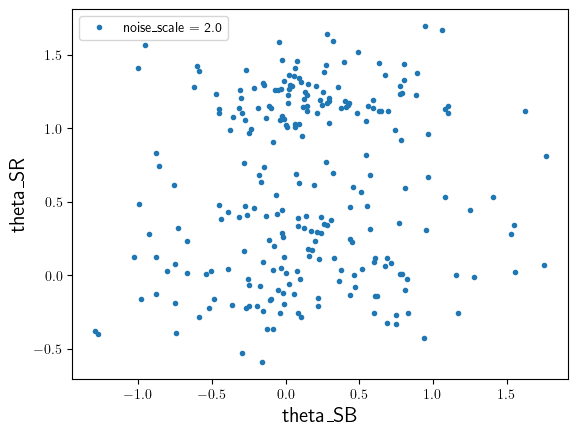

In [8]:
for noise_scale in [2.0]:
    plt.plot(results_df.loc[results_df["noise_scale"] == noise_scale]["theta_SB"], 
             results_df.loc[results_df["noise_scale"] == noise_scale]["theta_SR"], "o", label=f"noise_scale = {noise_scale}")
plt.xlabel("theta_SB")
plt.ylabel("theta_SR")
plt.legend()
plt.show()


In [11]:
from itertools import product

print("Without tilt correction")

for signal_ratio in [0.0, 0.005, 0.0075, 0.01, 0.02]:
    print(f"signal_ratio = {signal_ratio}")
    display(results_df.groupby(["signal_ratio", "noise_scale"]).mean().loc[(signal_ratio, )])
    print("-" * 100)

Without tilt correction
signal_ratio = 0.0


,seed,SR_size,theta_SB,theta_SR,theta_SR_clipped,max_diff_SB,max_diff_SR,max_diff_SB_corrected,max_diff_SR_corrected,W_4b_SR,...,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SB_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,0.027727,0.090394,0.105672,0.006110,0.008272,0.004015,0.004958,56916.394531,...,85139.742188,1.243633,0.742597,0.308341,0.34,0.847530,0.08,0.285411,0.702371,0.231649
1.0,24.5,0.2,0.130950,0.161573,0.127829,0.005914,0.008346,0.003939,0.005321,56924.460938,...,99130.062500,1.212801,0.772138,0.346104,0.36,0.750518,0.06,0.219201,0.465450,0.169343
2.0,24.5,0.2,0.040720,-0.026977,-0.042464,0.006051,0.007946,0.003989,0.005473,56887.191406,...,108049.843750,1.093632,0.752876,0.372329,0.20,0.780544,0.04,0.239545,0.419152,0.165624
3.0,24.5,0.2,0.152623,0.173295,0.105078,0.006858,0.009268,0.004257,0.005941,56955.136719,...,130715.453125,1.261093,0.808204,0.284267,0.36,0.742004,0.10,0.357421,0.416873,0.245949
inf,24.5,0.2,0.233449,0.195066,0.136145,0.007094,0.009437,0.004003,0.006073,57001.625000,...,140657.812500,1.283782,0.826030,0.295887,0.36,0.672645,0.12,0.273820,0.288378,0.192860


----------------------------------------------------------------------------------------------------
signal_ratio = 0.005


,seed,SR_size,theta_SB,theta_SR,theta_SR_clipped,max_diff_SB,max_diff_SR,max_diff_SB_corrected,max_diff_SR_corrected,W_4b_SR,...,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SB_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,-0.019526,0.107227,0.090146,0.006282,0.007726,0.004126,0.004777,56921.050781,...,86082.343750,1.156014,0.713616,0.363740,0.26,0.826851,0.04,0.208288,0.611358,0.169955
1.0,24.5,0.2,0.157503,0.086972,0.089830,0.006437,0.008769,0.004134,0.005110,56918.023438,...,96548.203125,1.275663,0.743137,0.274894,0.36,0.803986,0.06,0.251543,0.507425,0.197429
2.0,24.5,0.2,0.215250,0.145560,0.113045,0.006559,0.007699,0.004171,0.005414,56933.804688,...,121234.601562,1.061196,0.745735,0.422241,0.22,0.783138,0.06,0.242888,0.478725,0.176890
3.0,24.5,0.2,0.288225,0.291581,0.206175,0.006915,0.009577,0.004147,0.005883,56993.714844,...,140508.296875,1.304683,0.801469,0.277346,0.30,0.745189,0.08,0.356146,0.422585,0.265988
inf,24.5,0.2,0.320463,0.310706,0.228112,0.008248,0.010844,0.004175,0.005933,57018.640625,...,155746.312500,1.476581,0.807819,0.193689,0.56,0.734110,0.08,0.356496,0.378894,0.267603


----------------------------------------------------------------------------------------------------
signal_ratio = 0.0075


...

----------------------------------------------------------------------------------------------------
signal_ratio = 0.01


,seed,SR_size,theta_SB,theta_SR,theta_SR_clipped,max_diff_SB,max_diff_SR,max_diff_SB_corrected,max_diff_SR_corrected,W_4b_SR,...,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SB_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,0.330194,1.156580,0.556997,0.006374,0.030940,0.004118,0.019373,56808.929688,...,104799.140625,4.522970,2.833606,4.332919e-02,0.92,0.244830,0.68,1.162885,0.683093,0.563302
1.0,24.5,0.2,0.104283,1.106958,0.541916,0.006678,0.036397,0.004000,0.022124,56852.378906,...,144662.265625,5.080918,3.133222,2.893521e-03,0.98,0.090105,0.80,1.106958,0.585230,0.541916
2.0,24.5,0.2,0.118077,1.239929,0.348114,0.006070,0.041257,0.004270,0.033012,56834.566406,...,152847.078125,5.579822,4.471561,9.128794e-07,1.00,0.000995,1.00,1.239929,0.348114,0.348114
3.0,24.5,0.2,0.143073,1.277154,0.339468,0.006481,0.041533,0.004228,0.034181,56902.855469,...,161753.812500,5.573449,4.587294,2.389495e-14,1.00,0.000006,1.00,1.277154,0.339468,0.339468
inf,24.5,0.2,0.239066,1.147437,0.319932,0.007390,0.042868,0.004199,0.034583,56923.910156,...,183781.062500,5.737054,4.633440,3.887412e-20,1.00,0.002393,0.98,1.147437,0.320211,0.319932


----------------------------------------------------------------------------------------------------
signal_ratio = 0.02


,seed,SR_size,theta_SB,theta_SR,theta_SR_clipped,max_diff_SB,max_diff_SR,max_diff_SB_corrected,max_diff_SR_corrected,W_4b_SR,...,W2_3b_SR,normalized_max_cdf_diff_SR,normalized_max_cdf_diff_SR_corrected,p_value_SR,rejected_SR,p_value_SR_corrected,rejected_SR_corrected,theta_SR_abs,theta_SB_abs,theta_SR_clipped_abs
noise_scale,,,,,,,,,,,,,,,,,,,,,
0.5,24.5,0.2,0.522875,1.910746,0.582865,0.006602,0.083010,0.003804,0.062949,56710.671875,...,129613.046875,11.660916,8.914355,3.868431e-07,1.0,1.290628e-02,0.94,1.910746,0.605004,0.582865
1.0,24.5,0.2,0.395918,1.507284,0.473729,0.006776,0.109274,0.004015,0.082225,56744.871094,...,124812.906250,15.041532,11.366458,0.000000e+00,1.0,7.557898e-03,0.98,1.507284,0.477215,0.473729
2.0,24.5,0.2,0.215520,1.203339,0.361165,0.006436,0.116241,0.004249,0.090802,56778.148438,...,154597.187500,15.267635,12.007617,0.000000e+00,1.0,2.873824e-02,0.96,1.203339,0.371433,0.361165
3.0,24.5,0.2,0.043705,1.158370,0.365754,0.006990,0.116847,0.004315,0.089970,56888.191406,...,174315.687500,15.174016,11.741146,0.000000e+00,1.0,2.692932e-03,0.98,1.158370,0.369543,0.365754
inf,24.5,0.2,0.194862,1.008125,0.262451,0.007006,0.115693,0.004320,0.094174,56901.296875,...,152439.796875,15.072092,12.285635,0.000000e+00,1.0,4.562682e-10,1.00,1.008125,0.262451,0.262451


----------------------------------------------------------------------------------------------------


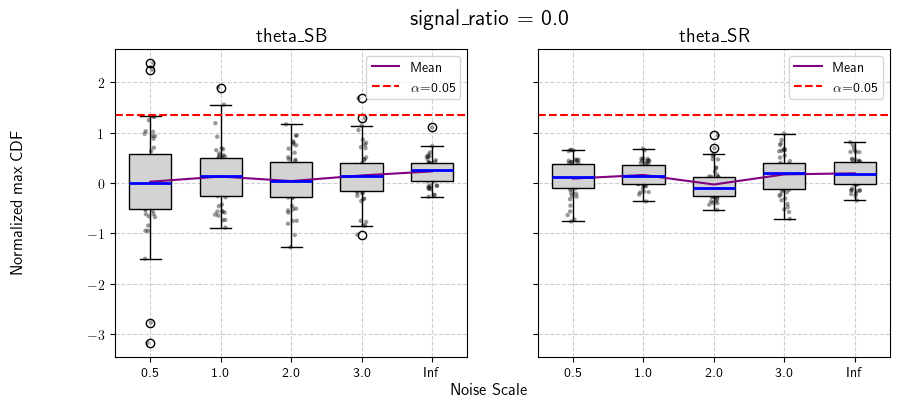

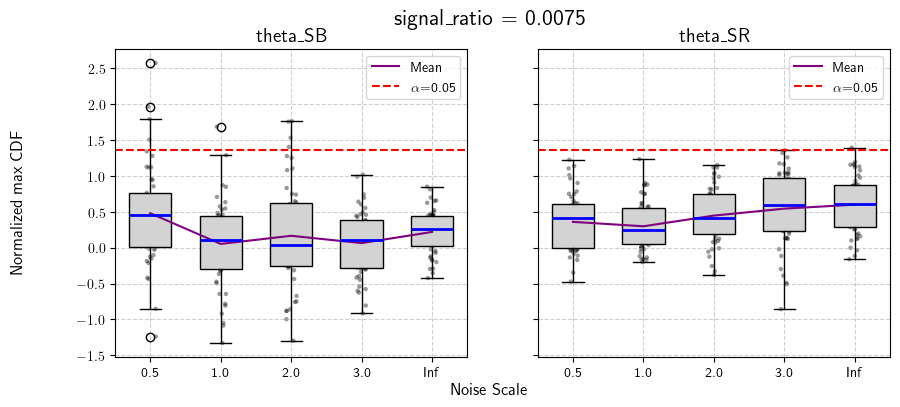

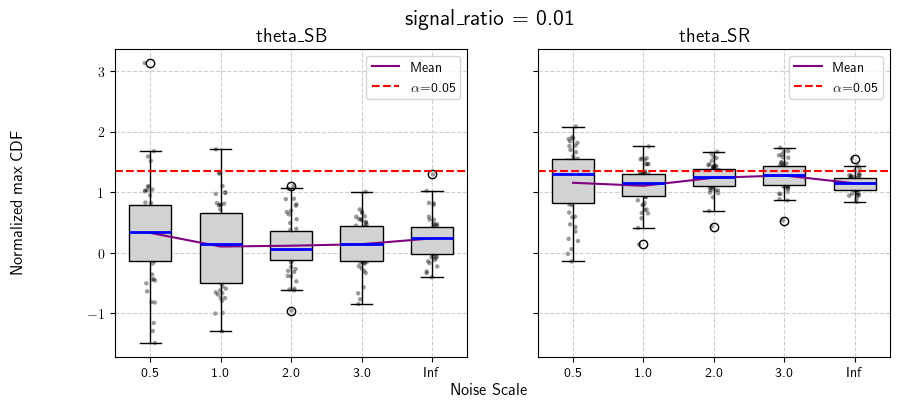

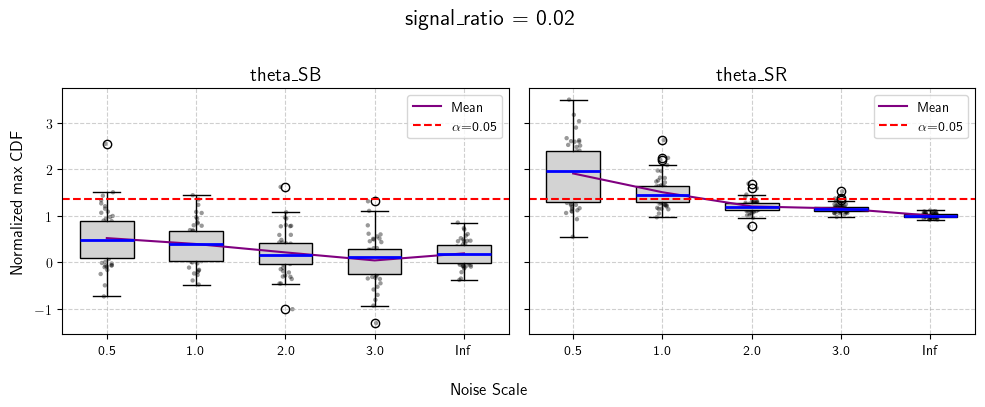

In [12]:
for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    # collect the data for each noise scale
    for i, key in enumerate(["theta_SB", 
                             "theta_SR"]):
        ax = axs[i]
        
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["noise_scale"] == ns),
                key
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
        
        ax.axhline(y=c_alpha(sig_level), color="red", linestyle="--", label=rf"$\alpha$={sig_level}")
            
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(key, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


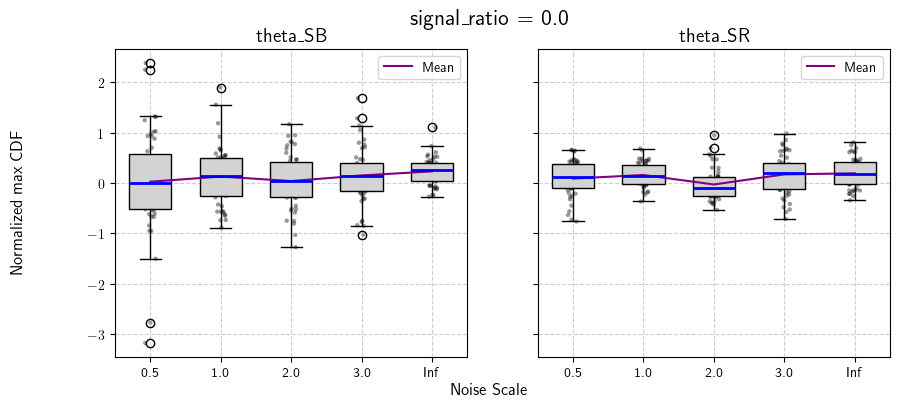

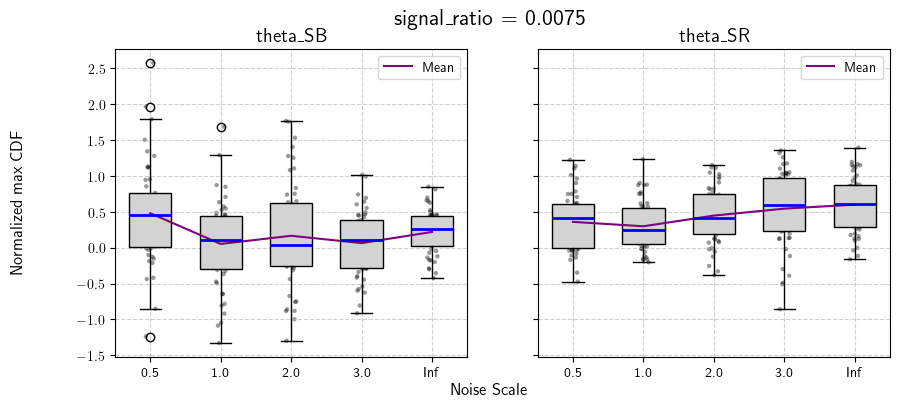

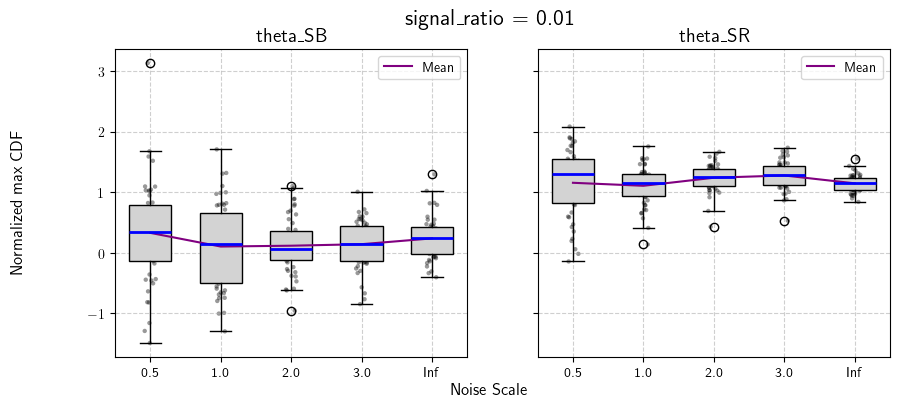

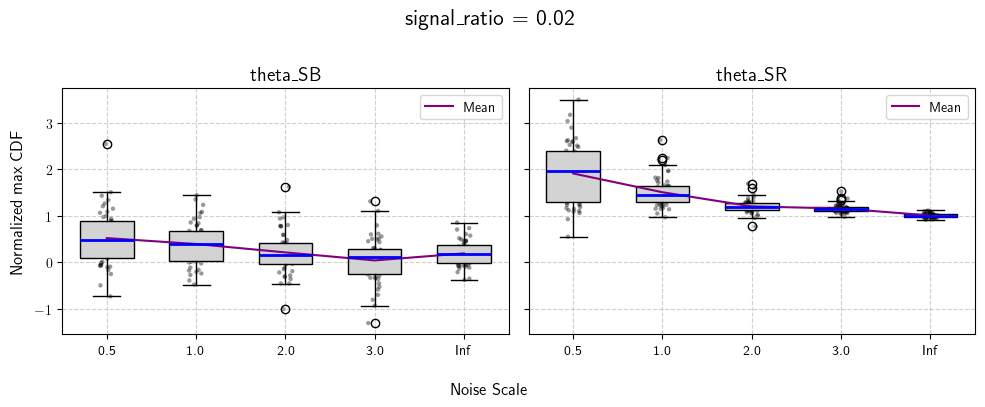

In [17]:
for signal_ratio in [0.0, 0.0075, 0.01, 0.02]:
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)
    fig.suptitle(f"signal_ratio = {signal_ratio}", fontsize=16)
    fig.supxlabel("Noise Scale", fontsize=12)
    fig.supylabel("Normalized max CDF", fontsize=12)
    
    noise_scales = [0.5, 1.0, 2.0, 3.0, np.inf]
    x_positions = np.arange(len(noise_scales))
    x_labels = [str(ns) if np.isfinite(ns) else "Inf" for ns in noise_scales]
    
    # collect the data for each noise scale
    for i, key in enumerate(["theta_SB", "theta_SR"]):
        ax = axs[i]
        
        data = []
        for ns in noise_scales:
            group = results_df.loc[
                (results_df["signal_ratio"] == signal_ratio) &
                (results_df["noise_scale"] == ns),
                key
            ]
            data.append(group.values)
        
        # draw boxplot
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.6,
            notch=False,
            patch_artist=True,
            showfliers=True
        )
        
        # optional: style the boxes
        for box in bp['boxes']:
            box.set(facecolor='lightgray', edgecolor='black')
        for whisker in bp['whiskers']:
            whisker.set(color='black')
        for cap in bp['caps']:
            cap.set(color='black')
        for median in bp['medians']:
            median.set(color='blue', linewidth=2)
        # mean
        mean = np.mean(data, axis=1)
        ax.plot(x_positions, mean, color="purple", label="Mean")
        
        # … inside your SR_size loop, after bp = ax.boxplot(...)
        for xi, yvals in zip(x_positions, data):
            # generate jitters around xi (width ≈ 0.08)
            jitters = np.random.uniform(-0.08, 0.08, size=len(yvals))
            ax.scatter(xi + jitters, yvals,
                    alpha=0.4,         # semi-transparent
                    color='black',
                    s=10,              # marker size
                    edgecolors='none')
            
        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_title(key, fontsize=14)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc="upper right")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
